## CSIS 1230 – Week 1 (Monday)
## **Topic:** Object-Oriented Programming in Python


---

### **Today's Objectives**

- Course Structure & Assessment

- Understand concept of objects in Python

- Define and create Python classes and objects

- Explain attributes and methods in Python

- Create a class, create objects and call methods

### **Course Overview**
- Term: Spring 2026
- Prerequisite: CSIS 1210
- Format: Mon/Wed Lectures, Fri Labs
- Textbooks:
  - *Think Python* (Ch. 15–19)
  - *Python for Everybody* (Ch. 12, 13, 15)

## **1. What is an Object?**

An **object** bundles:

- **Attributes** (data)

- **Methods** (functions that operate on the data)



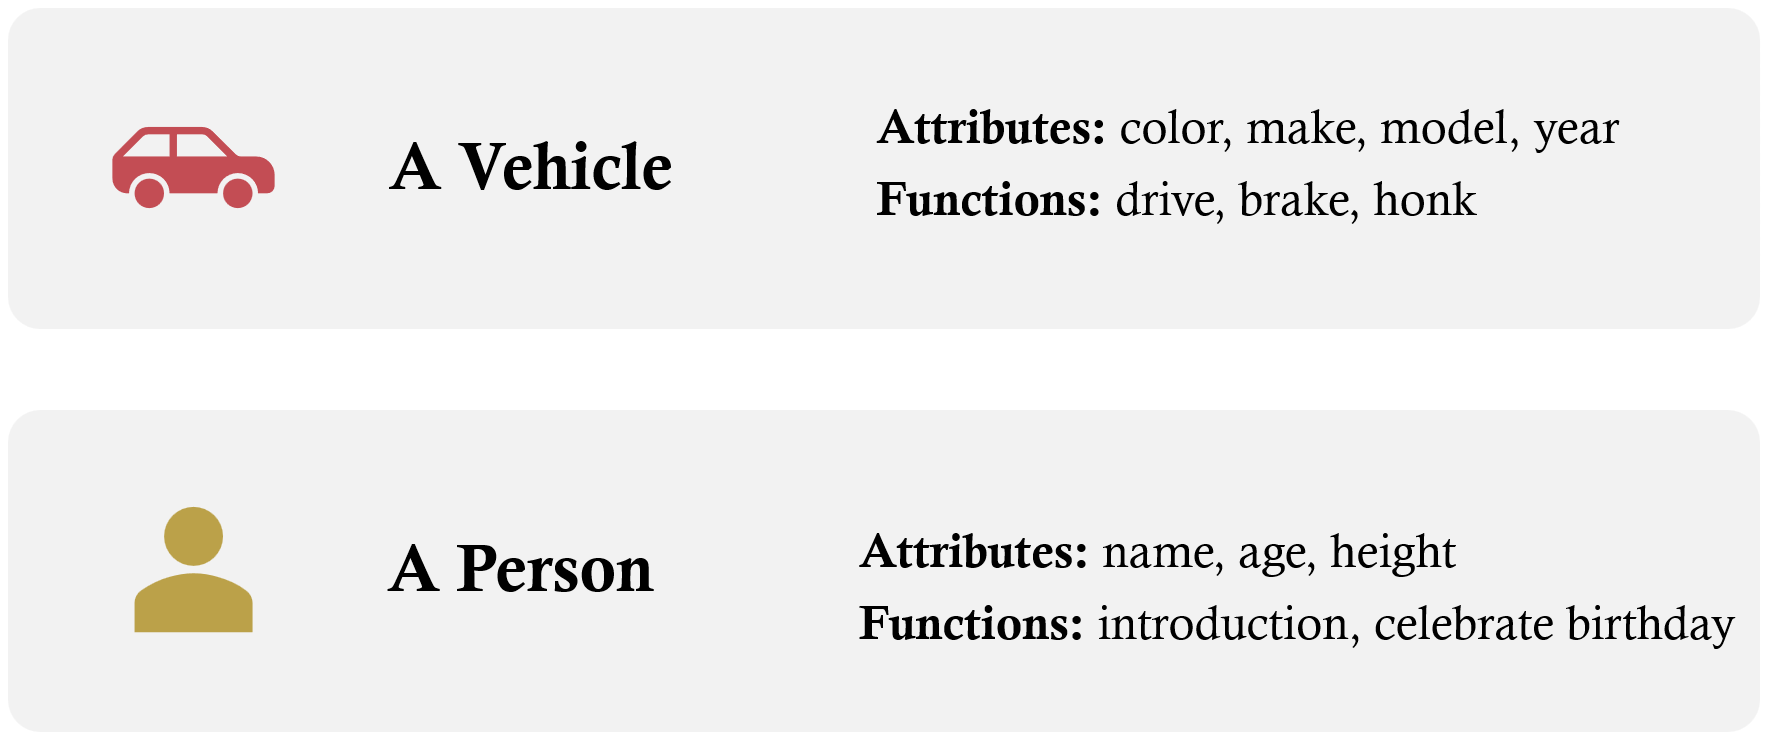

In [ ]:

class Person:
    def __init__(self, first_name, last_name, age):
        self.first_name = first_name
        self.last_name = last_name
        self.age = age

    def introduction(self):
        return f"My name is {self.first_name} {self.last_name} and I am {self.age} years old."

    def celebrate_birthday(self):
        self.age += 1
        return f"Happy birthday {self.first_name}! You are now {self.age}."
        
person = Person("John", "Doe", 30)
print(person.introduction())
print(person.celebrate_birthday())


### **2. Class vs Instance Attributes**

In [ ]:

class Vehicle:
    color = "green"  # class attribute

    def __init__(self, make, model, year):
        self.make = make
        self.model = model
        self.year = year

    def __str__(self):
        return f"{self.year} {self.make} {self.model}"

    def drive(self):
        print(f"{self.make} {self.model} driving at 35 mph")

v1 = Vehicle("Toyota", "Camry", 2024)
v2 = Vehicle("Ford", "Fiesta", 2024)

print(v1)
v2.drive()


### **3. Self Explained**

- **Identity:** Object needs to know “Who am I? when executing methods
- **Scope:** Distinguishes instance variables from local variables.
- **Consistency:** Python automatically passes the instance as first argument


**Without self**

In [ ]:
class BrokenBankAccount:
  def __init__(balance): # missing self
    balance = balance    # local variable not instance 


account = BrokenBankAccount(100)  
print(account.balance)    # Error: no class attribute balance

**With self**

In [ ]:
class BankAccount:
    def __init__(self,balance):
       self.balance = balance        # stores on instance

    def deposit(self, amount):
       self.balance += amount  # modifies account


alice_account = BankAccount(100)
alice_account.deposit(50)
print(alice_account.balance)
    


### **4. Why Object-Oriented Programming?**

- Reusability: Write once, use multiple times.

- Maintainability: Easier to update and debug

- Modularity: Break code into manageable pieces.

- Modeling real-world systems: it's a **modeling philosophy** that mirrors how humans naturally understand complex systems. Here's why it's indispensable in modern software development, illustrated through real-world parallels

### **4.1  Modularity**

**Core Idea**
**Modularity** means breaking a complex problem into **small, focused components**,  
where each component has **one responsibility**.

---

**Real-World Analogy: Processing an Order**

When a customer places an order, several things must happen:
- Items must be validated
- Payment must be processed
- Inventory must be updated
- A confirmation must be sent

---

**❌ Procedural Approach (Not Modular)**

All logic lives in **one function**.

```python
def process_order(items, user, payment):
    validate_items(items)
    charge_user(user, payment)
    update_inventory(items)
    send_confirmation(user, items)
```

**Problems:**
- One function does too much
- Hard to change payment logic without touching everything
- Difficult to test individual steps
- Code becomes fragile as it grows


✅ **OOP Approach (Modular)**

Each responsibility is handled by its own class.
```python
class Order:
    def __init__(self, items, user):
        self.items = items
        self.user = user

    def validate(self):
        print("Validating order items")

    def fulfill(self):
        print("Order fulfilled")


class Payment:
    def __init__(self, payment_info):
        self.payment_info = payment_info

    def charge(self, user):
        print("Charging user")


class Notifier:
    def notify(self, user):
        print("Sending confirmation")

```

**Orchestrating the workflow**

```python 

def process_order(items, user, payment_info):
    order = Order(items, user)
    payment = Payment(payment_info)
    notifier = Notifier()

    order.validate()
    payment.charge(user)
    order.fulfill()
    notifier.notify(user)

```


### **4.2. Encapsulation**
Encapsulation hides internal state and forces interaction through methods.

**ATM Machine System:**

- Prevents direct balance manipulation (account.__balance = 1000000)

- Enforces validation rules in one place

- Changes to internal logic (e.g., adding transaction fees) don't break external code.



In [ ]:

class BankAccount:
    def __init__(self, balance):
        self.__balance = balance             # private

    def deposit(self, amount):
        if amount > 0:
            self.__balance += amount

    def withdraw(self, amount):
        if 0 < amount <= self.__balance:
            self.__balance -= amount        # controlled access

    def get_balance(self):
        return self.__balance

acct = BankAccount(100)
acct.deposit(50)
acct.withdraw(30)
print(acct.get_balance())


### **4.3 Polymorphism & Inheritance**

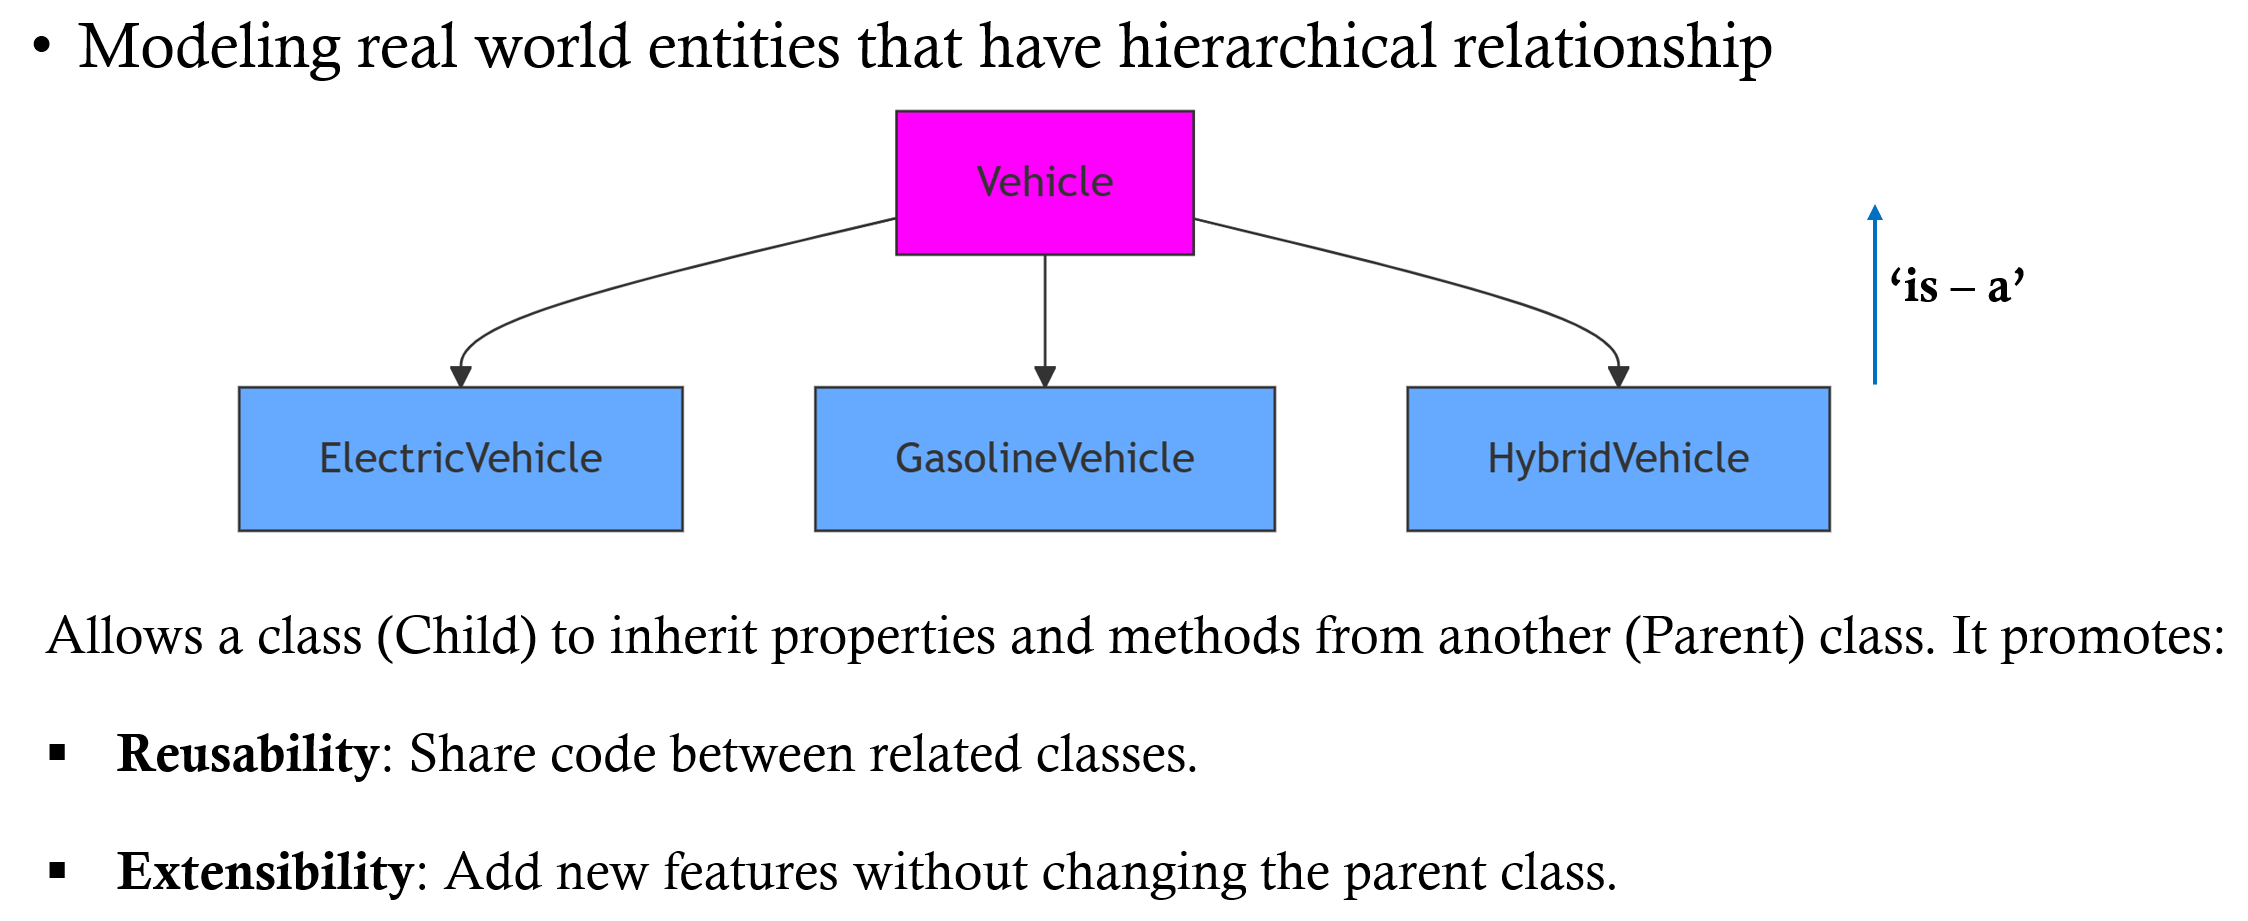

In [ ]:
# Parent class
class Vehicle:
    def __init__(self, make, model):
        self.make = make
        self.model = model

    def drive(self):
        print(f"{self.make} {self.model} is driving")


# Child class: ElectricVehicle IS-A Vehicle
class ElectricVehicle(Vehicle):
    def __init__(self, make, model, battery_capacity):
        super().__init__(make, model)
        self.battery_capacity = battery_capacity

    def charge(self):
        print(f"Charging battery ({self.battery_capacity} kWh)")


# Child class: GasolineVehicle IS-A Vehicle
class GasolineVehicle(Vehicle):
    def __init__(self, make, model, fuel_capacity):
        super().__init__(make, model)
        self.fuel_capacity = fuel_capacity

    def refuel(self):
        print(f"Refueling tank ({self.fuel_capacity} gallons)")


# Child class: HybridVehicle IS-A Vehicle
class HybridVehicle(Vehicle):
    def __init__(self, make, model, battery_capacity, fuel_capacity):
        super().__init__(make, model)
        self.battery_capacity = battery_capacity
        self.fuel_capacity = fuel_capacity

    def switch_mode(self):
        print("Switching between electric and gasoline mode")


In [ ]:
ev = ElectricVehicle("Tesla", "Model 3", 75)
gv = GasolineVehicle("Toyota", "Camry", 14)
hv = HybridVehicle("Toyota", "Prius", 8, 11)

ev.drive()
ev.charge()

gv.drive()
gv.refuel()

hv.drive()
hv.switch_mode()


### **4.4 Abstraction with Abstract Base Classes**

**Intuition:** Hiding complexity, exposing essentials. Let’s you use shapes without knowing geometry formulas

*Abstract classes* 

- cannot be instantiated directly
- Serves as a template for other classes
- Can call `area()` without math knowledge
- Prevent errors
- Update methods without breaking user code


In [ ]:

from abc import ABC, abstractmethod

class Shape(ABC):
    @abstractmethod
    def area(self):
        pass

    @abstractmethod
    def perimeter(self):
        pass

class Rectangle(Shape):
    def __init__(self, width, height):
        self.width = width
        self.height = height

    def area(self):
        return self.width * self.height

    def perimeter(self):
        return 2 * (self.width + self.height)

rect = Rectangle(10, 5)
print(rect.area())
print(rect.perimeter())


### **5. Good OOP Habits**

- Use meaningful names

- Single Responsibility Principle: A class should do one thing i.e. high cohesion / low coupling

- DRY: (Don’t repeat yourself): Abstract repeated logic into methods or parent classes.

- Test small and often: Write simple test snippets to validate behavior as you code

### **6. Class Exercise**

- Create a `Student` class that inherits from `Person`

- Add attributes and methods

- Handle edge cases (if applicable)




In [1]:
# Code goes in here